In [35]:
import os
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
import datetime as dt
import yfinance as yf

warnings.filterwarnings('ignore')
rcParams['figure.figsize'] = 15, 6

# Chọn mã cổ phiếu phù hợp với tên notebook
bank_stock_name = "ACB.VN"

model_dir = os.path.join(os.getcwd(), '..', 'Save_model_KNN')
stock_model_dir = os.path.join(model_dir, bank_stock_name)
print('Model dir:', stock_model_dir)
if not os.path.exists(stock_model_dir):
    os.makedirs(stock_model_dir, exist_ok=True)

Model dir: c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN


In [36]:
def save_model(stock_model_dir, model_name, model):
    model_name = model_name + ".pkl"
    model_path = os.path.join(stock_model_dir, model_name)
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved model to {model_path}")

def load_model(stock_model_dir, model_name):
    model_name = model_name + ".pkl"
    model_path = os.path.join(stock_model_dir, model_name)
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    print(f"Loaded model from {model_path}")
    return model

def update_model_loss(stock_model_dir, model_name, rmse, mae, r2):
    model_loss_log = os.path.join(stock_model_dir, "model_loss.json")
    loss_detail = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }
    try:
        with open(model_loss_log, 'r') as f:
            model_loss = json.load(f)
    except:
        model_loss = {}
    model_loss[model_name] = loss_detail

    with open(model_loss_log, 'w') as f:
        json.dump(model_loss, f, indent=4, ensure_ascii=False)

In [37]:
stock = pd.read_csv(f'../data/{bank_stock_name}.csv')
stock.head()

,Price,Date,Close,High,Low,Open,Volume
0,0,2020-11-26,10515.915039,10631.052834,10362.397979,10477.535774,25156125
1,1,2020-11-27,10439.156250,10592.673306,10439.156250,10554.294042,15970407
2,2,2020-11-30,10439.156250,10515.914778,10362.397722,10515.914778,21254075
3,3,2020-12-01,10477.536133,10477.536133,10285.639801,10439.156867,22004479
4,4,2020-12-09,10957.276367,11110.793430,10669.431429,10784.569226,57510292


In [38]:
# Kiểm tra thông tin dữ liệu
print(f"Số lượng mẫu: {len(stock)}")
print(f"\nThông tin cột:")
print(stock.info())
print(f"\nThống kê mô tả:")
print(stock.describe())

Số lượng mẫu: 1242

Thông tin cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   1242 non-null   int64  
 1   Date    1242 non-null   object 
 2   Close   1242 non-null   float64
 3   High    1242 non-null   float64
 4   Low     1242 non-null   float64
 5   Open    1242 non-null   float64
 6   Volume  1242 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 68.1+ KB
None

Thống kê mô tả:
             Price         Close          High           Low          Open  \
count  1242.000000   1242.000000   1242.000000   1242.000000   1242.000000   
mean    620.500000  17194.079429  17375.598361  17023.141925  17206.193146   
std     358.678826   3740.571453   3766.288564   3731.069865   3755.788830   
min       0.000000   9825.088867  10247.260808   9402.915644   9402.915644   
25%     310.250000  14846.847900  14973.904300  146

In [39]:
# Chuẩn bị dữ liệu
# Chuyển đổi cột Date sang datetime và đặt làm index
stock['Date'] = pd.to_datetime(stock['Date'])
stock.set_index('Date', inplace=True)
stock = stock.sort_index()

# Chọn cột Close để dự đoán
data = stock[['Close']].copy()
print(f"Dữ liệu sau khi xử lý:\n{data.head()}")
print(f"Shape: {data.shape}")

Dữ liệu sau khi xử lý:
                   Close
Date                    
2020-11-26  10515.915039
2020-11-27  10439.156250
2020-11-30  10439.156250
2020-12-01  10477.536133
2020-12-09  10957.276367
Shape: (1242, 1)


In [40]:
# Tạo các đặc trưng (features) cho mô hình KNN
# Sử dụng các giá trị trước đó để dự đoán giá trị hiện tại
def create_features(data, n_lags=5):
    """
    Tạo features từ các giá trị lag (giá trị ở các ngày trước)
    n_lags: số lượng ngày trước đó sử dụng làm features
    """
    df = data.copy()
    
    # Tạo lag features
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['Close'].shift(i)
    
    # Loại bỏ các hàng có giá trị NaN
    df = df.dropna()
    
    return df

# Tạo features với 5 ngày lag
n_lags = 5
df_features = create_features(data, n_lags=n_lags)
print(f"Dữ liệu với features:\n{df_features.head()}")
print(f"Shape: {df_features.shape}")

Dữ liệu với features:
                   Close         lag_1         lag_2         lag_3  \
Date                                                                 
2020-12-10  10727.000000  10957.276367  10477.536133  10439.156250   
2020-12-11  10822.948242  10727.000000  10957.276367  10477.536133   
2020-12-14  10822.948242  10822.948242  10727.000000  10957.276367   
2020-12-15  10746.189453  10822.948242  10822.948242  10727.000000   
2020-12-16  10842.137695  10746.189453  10822.948242  10822.948242   

                   lag_4         lag_5  
Date                                    
2020-12-10  10439.156250  10515.915039  
2020-12-11  10439.156250  10439.156250  
2020-12-14  10477.536133  10439.156250  
2020-12-15  10957.276367  10477.536133  
2020-12-16  10727.000000  10957.276367  
Shape: (1237, 6)


In [41]:
# Chia dữ liệu thành train và test set (80-20)
train_size = int(len(df_features) * 0.8)
train_data = df_features[:train_size]
test_data = df_features[train_size:]

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Tách X (features) và y (target)
X_train = train_data[[f'lag_{i}' for i in range(1, n_lags + 1)]].values
y_train = train_data['Close'].values

X_test = test_data[[f'lag_{i}' for i in range(1, n_lags + 1)]].values
y_test = test_data['Close'].values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Train size: 989
Test size: 248

X_train shape: (989, 5)
y_train shape: (989,)
X_test shape: (248, 5)
y_test shape: (248,)


In [42]:
# Chuẩn hóa dữ liệu (KNN cần dữ liệu được chuẩn hóa)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dữ liệu đã được chuẩn hóa")
print(f"X_train_scaled range: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"X_test_scaled range: [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]")

Dữ liệu đã được chuẩn hóa
X_train_scaled range: [0.0000, 1.0000]
X_test_scaled range: [0.6914, 1.6390]


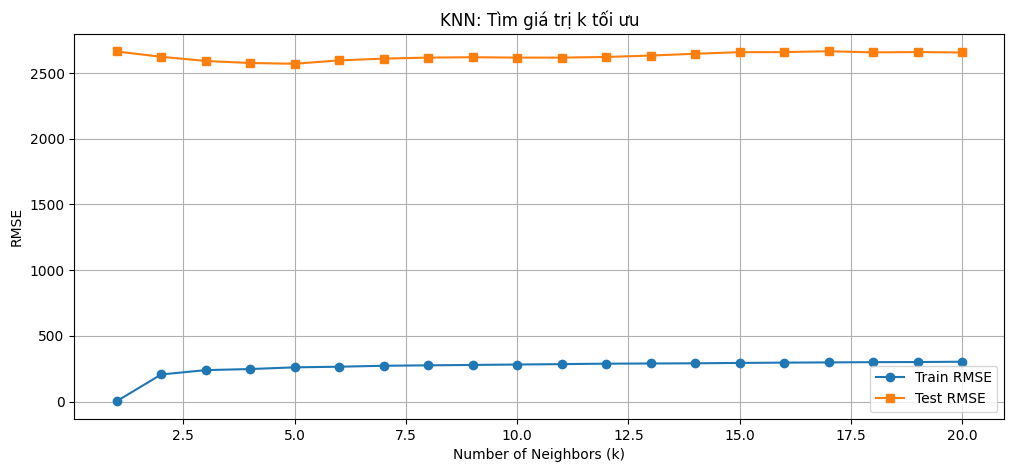


Giá trị k tốt nhất: 5
Test RMSE tốt nhất: 2570.4732


In [43]:
from sklearn.neighbors import KNeighborsRegressor

# Tìm giá trị k tối ưu
k_values = range(1, 21)
train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
plt.plot(k_values, train_errors, label='Train RMSE', marker='o')
plt.plot(k_values, test_errors, label='Test RMSE', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.title('KNN: Tìm giá trị k tối ưu')
plt.legend()
plt.grid(True)
plt.show()

# Tìm k tốt nhất
best_k = k_values[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
print(f"\nGiá trị k tốt nhất: {best_k}")
print(f"Test RMSE tốt nhất: {best_test_rmse:.4f}")

In [44]:
# Huấn luyện mô hình KNN với k tối ưu
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# Dự đoán
y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

print(f"Mô hình KNN đã được huấn luyện với k={best_k}")
print(f"Số lượng dự đoán trên tập train: {len(y_train_pred)}")
print(f"Số lượng dự đoán trên tập test: {len(y_test_pred)}")

Mô hình KNN đã được huấn luyện với k=5
Số lượng dự đoán trên tập train: 989
Số lượng dự đoán trên tập test: 248


In [45]:
# Đánh giá mô hình
# Tập train
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Tập test
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH KNN")
print("=" * 50)
print(f"\nTập Train:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTập Test:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")
print("=" * 50)

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH KNN

Tập Train:
  RMSE: 260.0498
  MAE:  186.7311
  R²:   0.9896

Tập Test:
  RMSE: 2570.4732
  MAE:  1640.1374
  R²:   -0.1984


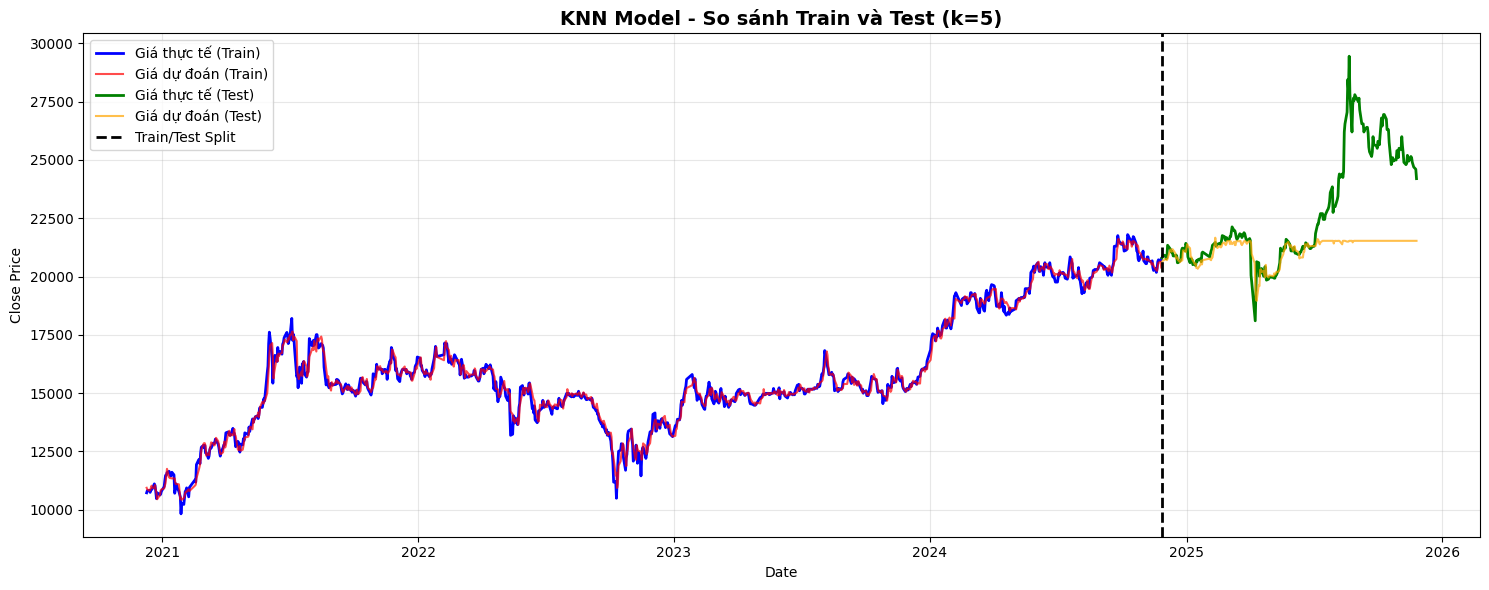

In [46]:
# Vẽ biểu đồ so sánh giá trị thực tế và dự đoán (gộp train và test)
plt.figure(figsize=(15, 6))

# Train set
plt.plot(train_data.index, y_train, label='Giá thực tế (Train)', color='blue', linewidth=2)
plt.plot(train_data.index, y_train_pred, label='Giá dự đoán (Train)', color='red', alpha=0.7, linewidth=1.5)

# Test set
plt.plot(test_data.index, y_test, label='Giá thực tế (Test)', color='green', linewidth=2)
plt.plot(test_data.index, y_test_pred, label='Giá dự đoán (Test)', color='orange', alpha=0.7, linewidth=1.5)

# Thêm đường phân cách giữa train và test
split_date = test_data.index[0]
plt.axvline(x=split_date, color='black', linestyle='--', linewidth=2, label='Train/Test Split')

plt.title(f'KNN Model - So sánh Train và Test (k={best_k})', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

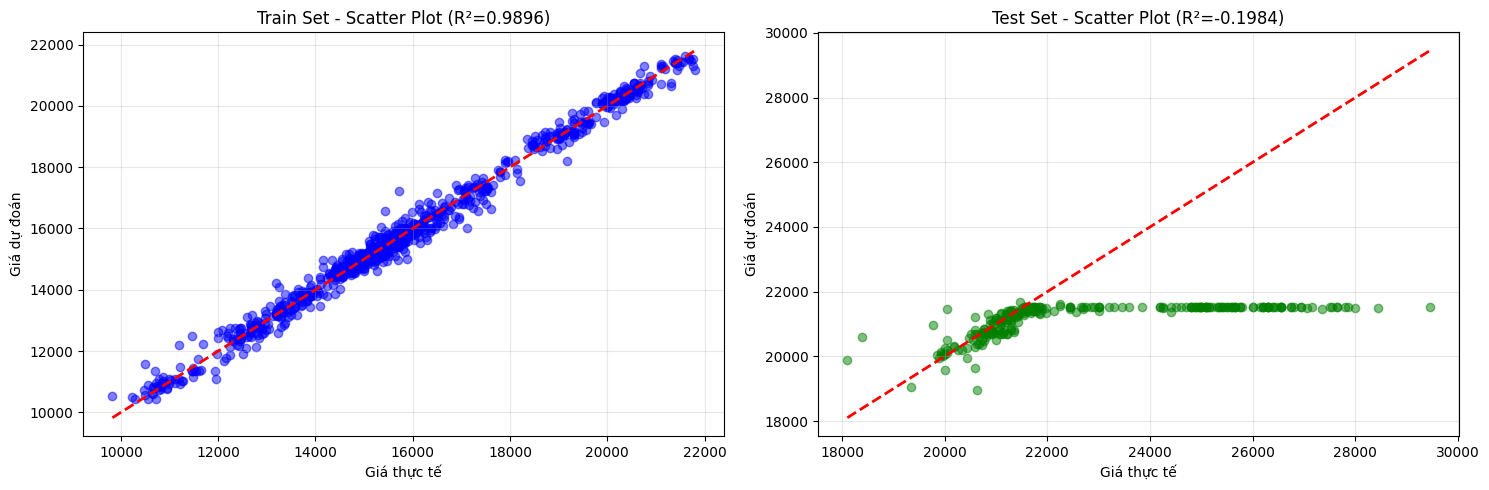

In [47]:
# Vẽ biểu đồ scatter plot để xem mối quan hệ giữa giá thực tế và dự đoán
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Giá thực tế')
axes[0].set_ylabel('Giá dự đoán')
axes[0].set_title(f'Train Set - Scatter Plot (R²={train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Giá thực tế')
axes[1].set_ylabel('Giá dự đoán')
axes[1].set_title(f'Test Set - Scatter Plot (R²={test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Lưu kết quả dự đoán
results_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Error': y_test - y_test_pred,
    'Abs_Error': np.abs(y_test - y_test_pred)
})

results_path = os.path.join(stock_model_dir, 'knn_predictions.csv')
results_df.to_csv(results_path, index=False)
print(f"Đã lưu kết quả dự đoán vào: {results_path}")

# Hiển thị một số kết quả
print(f"\nMột số kết quả dự đoán:")
print(results_df.head(10))

Đã lưu kết quả dự đoán vào: c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN\knn_predictions.csv

Một số kết quả dự đoán:
        Date        Actual     Predicted       Error   Abs_Error
0 2024-11-27  20802.177734  20611.179297  190.998437  190.998437
1 2024-11-28  20885.220703  20685.917969  199.302734  199.302734
2 2024-11-29  20926.742188  20694.222266  232.519922  232.519922
3 2024-12-02  20885.220703  20744.047656  141.173047  141.173047
4 2024-12-03  20760.656250  20760.656641   -0.000391    0.000391
5 2024-12-04  20802.177734  20702.526172   99.651562   99.651562
6 2024-12-05  21341.955078  20760.656250  581.298828  581.298828
7 2024-12-06  21300.433594  20876.917187  423.516406  423.516406
8 2024-12-09  21175.869141  21159.261719   16.607422   16.607422
9 2024-12-10  21051.306641  21134.348047  -83.041406   83.041406


In [49]:
# Lưu mô hình KNN
save_model(stock_model_dir, "knn_model", knn_model)

# Lưu scaler
save_model(stock_model_dir, "knn_scaler", scaler)

# Lưu các thông số mô hình
model_params = {
    "n_neighbors": best_k,
    "n_lags": n_lags,
    "train_size": len(train_data),
    "test_size": len(test_data)
}
params_path = os.path.join(stock_model_dir, "knn_params.json")
with open(params_path, 'w') as f:
    json.dump(model_params, f, indent=4)
print(f"Đã lưu thông số mô hình vào: {params_path}")

Saved model to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN\knn_model.pkl
Saved model to c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN\knn_scaler.pkl
Đã lưu thông số mô hình vào: c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN\knn_params.json


In [50]:
# Lưu model loss (metrics)
update_model_loss(stock_model_dir, "KNN", test_rmse, test_mae, test_r2)

print("\n" + "=" * 50)
print("HOÀN THÀNH XÂY DỰNG MÔ HÌNH KNN")
print("=" * 50)
print(f"Mô hình: K-Nearest Neighbors (k={best_k})")
print(f"Cổ phiếu: {bank_stock_name}")
print(f"Số lags: {n_lags}")
print(f"\nĐộ chính xác trên tập test:")
print(f"  - RMSE: {test_rmse:.4f}")
print(f"  - MAE:  {test_mae:.4f}")
print(f"  - R²:   {test_r2:.4f}")
print(f"\nCác file đã được lưu tại: {stock_model_dir}")
print("=" * 50)


HOÀN THÀNH XÂY DỰNG MÔ HÌNH KNN
Mô hình: K-Nearest Neighbors (k=5)
Cổ phiếu: ACB.VN
Số lags: 5

Độ chính xác trên tập test:
  - RMSE: 2570.4732
  - MAE:  1640.1374
  - R²:   -0.1984

Các file đã được lưu tại: c:\Users\Dell\Documents\BIG_DATA_NHOM\Train_model_KNN\..\Save_model_KNN\ACB.VN
